# Task 2 - Wine Quality Prediction

## Objective

Train and compare multiple classification models to predict wine quality based on its physicochemical properties.

The models used are:

- Random Forest
- Stochastic Gradient Descent (SGD)
- Support Vector Classifier (SVC)

The original wine quality scores are converted into three classes:

- Low: quality 3-5
- Medium: quality 6
- High: quality 7-8

The models are evaluated using accuracy, classification report, and confusion matrix.

## Dataset

The dataset is the Red Wine Quality dataset from the UCI Machine Learning Repository.

It contains physicochemical measurements such as acidity, residual sugar, chlorides, sulfur dioxide, density, pH, sulphates and alcohol.

The target variable is the wine quality score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 1. Load the Wine Quality Dataset

The dataset is stored inside the `data` folder.

The CSV file uses semicolons as separators, so `sep=";"` is required while loading it.

In [4]:
from pathlib import Path
import pandas as pd

data_path = Path("../data/winequality-red.csv")

df = pd.read_csv(data_path, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1599, 12)


In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
print("Columns:")
print(df.columns.tolist())

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


### Dataset Structure Observation

The dataset contains 11 physicochemical features and one target variable, `quality`.

All predictor variables are numerical chemical measurements. The target is an integer wine quality score.

In [9]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 240


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## 2. Quality Score Distribution

Before creating classification classes, the distribution of the original quality scores is examined.

This is important because the UCI documentation notes that the wine-quality classes are not balanced.

In [13]:
quality_counts = df["quality"].value_counts().sort_index()

print(quality_counts)

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

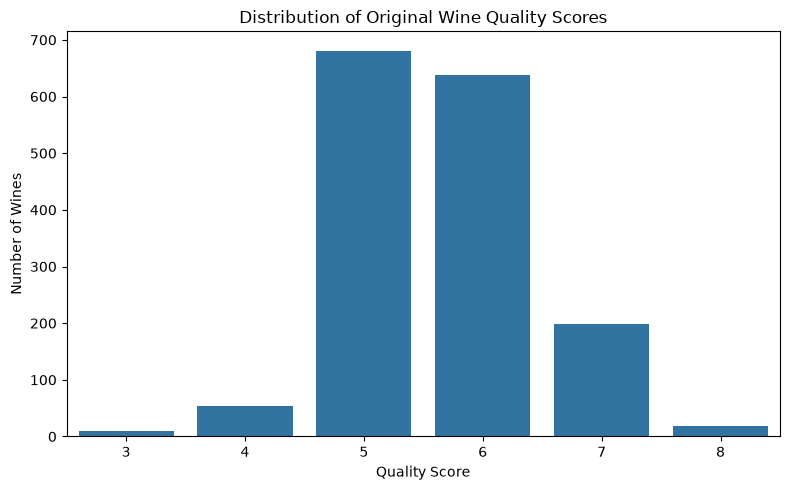

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality",
    order=sorted(df["quality"].unique())
)

plt.title("Distribution of Original Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")

plt.tight_layout()

plt.savefig("../images/quality_distribution.png", dpi=300)

plt.show()

### Quality Distribution Observation

The original quality scores are not evenly distributed.

Most observations are concentrated around the middle quality scores, while very low and very high quality scores occur much less frequently.

This creates class imbalance and can make classification models more likely to predict the majority class.

## 3. Distribution of Chemical Features

The distributions of all physicochemical features are examined to understand their ranges and possible skewness.

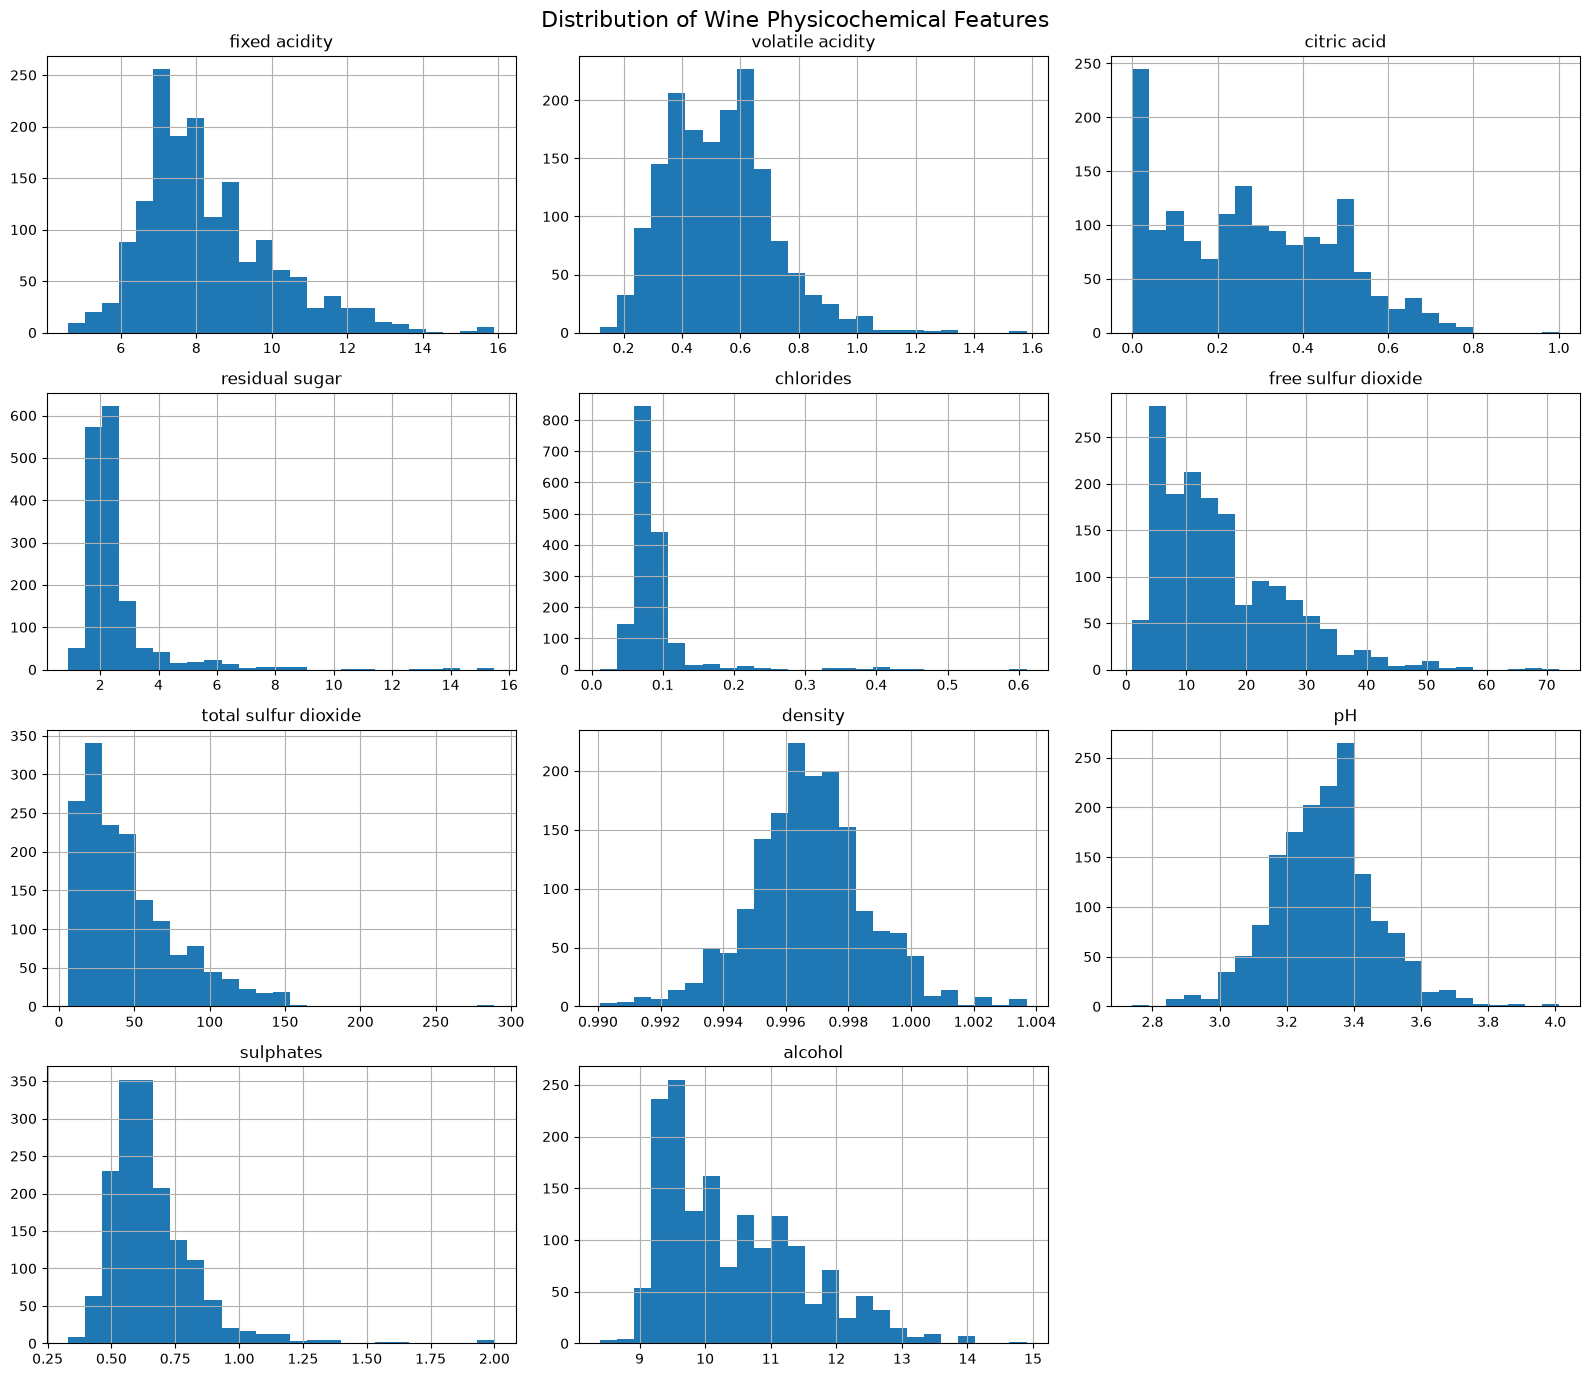

In [18]:
features = df.drop(columns="quality").columns

df[features].hist(
    figsize=(16, 14),
    bins=25
)

plt.suptitle(
    "Distribution of Wine Physicochemical Features",
    fontsize=16
)

plt.tight_layout()
plt.savefig("../images/feature_distributions.png", dpi=300)
plt.show()

### Feature Distribution Observation

The chemical variables have different ranges and distributions.

Some variables such as residual sugar, chlorides and sulfur dioxide show skewed distributions, while variables such as pH are concentrated within a narrower range.

Feature scaling will therefore be important for SGD and SVC models.

## 4. Correlation Analysis

A correlation heatmap is used to examine relationships between physicochemical features and the wine quality score.

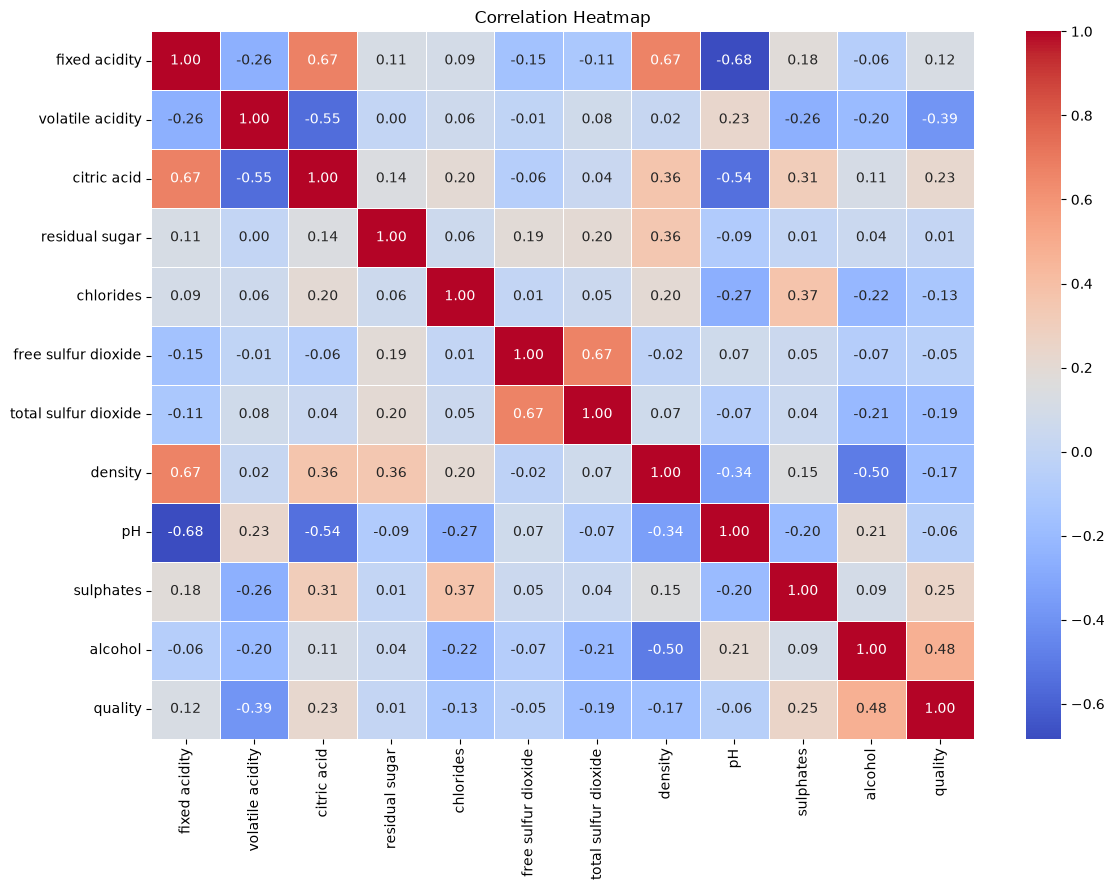

In [19]:
plt.figure(figsize=(12, 9))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("../images/correlation_heatmap.png", dpi=300)

plt.show()

In [20]:
quality_correlations = (
    correlation_matrix["quality"]
    .drop("quality")
    .sort_values(ascending=False)
)

print("Correlation with wine quality:")
display(quality_correlations.to_frame("Correlation"))

Correlation with wine quality:


,Correlation
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919
total sulfur dioxide,-0.185100


### Correlation Observation

The correlation analysis shows that different physicochemical properties have different relationships with wine quality.

Correlation does not imply causation. It only indicates the strength and direction of a linear relationship between two variables.

These relationships provide useful exploratory information before model training.

## 5. Feature Engineering: Quality Classes

The original quality score is converted into three ordered categories:

- Low = quality 3-5
- Medium = quality 6
- High = quality 7-8

This creates a multiclass classification problem.

In [21]:
def classify_quality(score):
    if score <= 5:
        return "Low"
    elif score == 6:
        return "Medium"
    else:
        return "High"


df["quality_class"] = df["quality"].apply(classify_quality)

df[["quality", "quality_class"]].head(10)

,quality,quality_class
0,5,Low
1,5,Low
2,5,Low
3,6,Medium
4,5,Low
5,5,Low
6,5,Low
7,7,High
8,7,High
9,5,Low


In [22]:
print(df["quality_class"].value_counts())

quality_class
Low       744
Medium    638
High      217
Name: count, dtype: int64


In [23]:
class_distribution = (
    df["quality_class"]
    .value_counts()
    .sort_index()
)

class_percentage = (
    df["quality_class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

distribution_table = pd.DataFrame({
    "Count": class_distribution,
    "Percentage": class_percentage.round(2)
})

distribution_table

,Count,Percentage
quality_class,,
High,217,13.57
Low,744,46.53
Medium,638,39.90


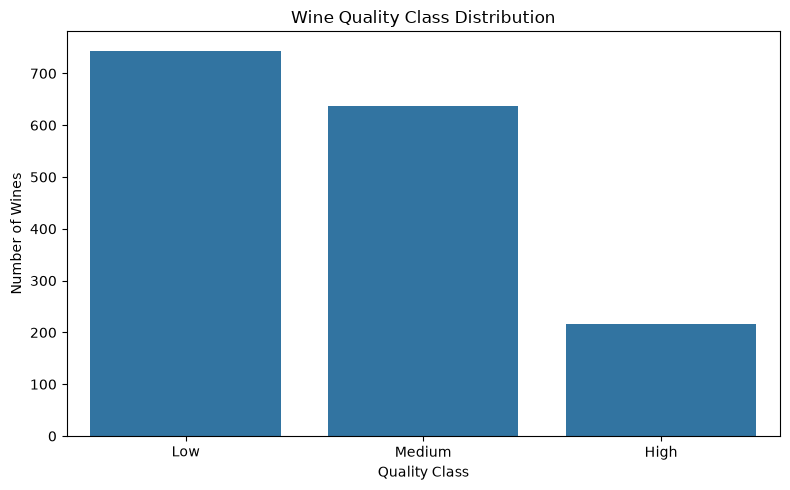

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality_class",
    order=["Low", "Medium", "High"]
)

plt.title("Wine Quality Class Distribution")
plt.xlabel("Quality Class")
plt.ylabel("Number of Wines")

plt.tight_layout()
plt.savefig("../images/class_distribution.png", dpi=300)

plt.show()

### Class Imbalance Observation

The three classes are not equally represented.

The High-quality class contains considerably fewer observations than the Low and Medium classes.

This imbalance can affect classification because a model may become biased toward the more frequent classes.

Therefore, accuracy alone should not be used to judge model performance. Precision, recall, F1-score and the confusion matrix should also be examined.

To reduce the effect of class imbalance during training, `class_weight="balanced"` will be used for the three classifiers.

## 6. Preparing Features and Target

The original `quality` score is excluded from the predictor variables because it is the source from which the new classification target was created.

The new `quality_class` variable becomes the target.

In [25]:
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1599, 11)
Target shape: (1599,)


## 7. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split.

Stratification is used so that the proportions of Low, Medium and High classes remain approximately the same in both sets.

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1279, 11)
Testing set: (320, 11)


In [29]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training class distribution:
quality_class
High      0.136044
Low       0.465207
Medium    0.398749
Name: proportion, dtype: float64

Testing class distribution:
quality_class
High      0.134375
Low       0.465625
Medium    0.400000
Name: proportion, dtype: float64


## 8. Model 1 — Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It can model nonlinear relationships and does not require feature scaling.

Class weighting is used to reduce the effect of class imbalance.

In [32]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.7375


In [34]:
from sklearn.metrics import classification_report
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        rf_pred,
        labels=["Low", "Medium", "High"],
        zero_division=0
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

         Low       0.82      0.81      0.81       149
      Medium       0.71      0.66      0.68       128
        High       0.58      0.74      0.65        43

    accuracy                           0.74       320
   macro avg       0.70      0.74      0.72       320
weighted avg       0.74      0.74      0.74       320



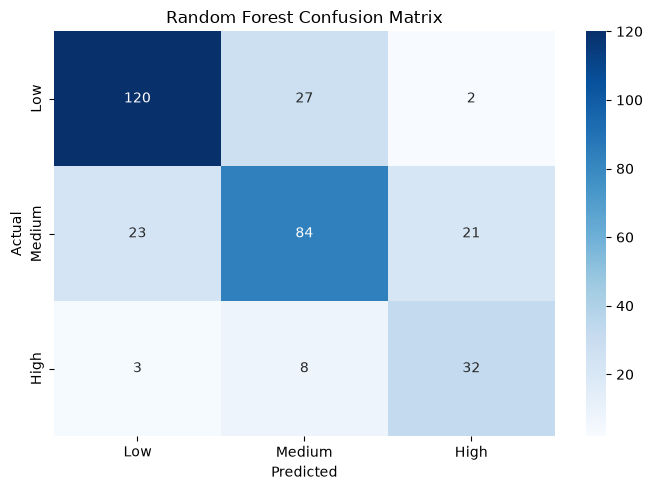

In [39]:
from sklearn.metrics import confusion_matrix
rf_cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("../images/random_forest_confusion_matrix.png", dpi=300)

plt.show()

## 9. Model 2 — Stochastic Gradient Descent Classifier

SGD trains the classifier using stochastic optimization.

Unlike Random Forest, SGD is sensitive to feature scale, so StandardScaler is applied before classification.

A pipeline is used to prevent data leakage.

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
sgd_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SGDClassifier(
        loss="log_loss",
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    ))
])

sgd_model.fit(X_train, y_train)

sgd_pred = sgd_model.predict(X_test)

sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", round(sgd_accuracy, 4))

SGD Accuracy: 0.5813


In [42]:
print("SGD Classification Report:\n")

print(
    classification_report(
        y_test,
        sgd_pred,
        labels=["Low", "Medium", "High"],
        zero_division=0
    )
)

SGD Classification Report:

              precision    recall  f1-score   support

         Low       0.69      0.78      0.73       149
      Medium       0.55      0.38      0.45       128
        High       0.33      0.51      0.40        43

    accuracy                           0.58       320
   macro avg       0.53      0.56      0.53       320
weighted avg       0.59      0.58      0.57       320



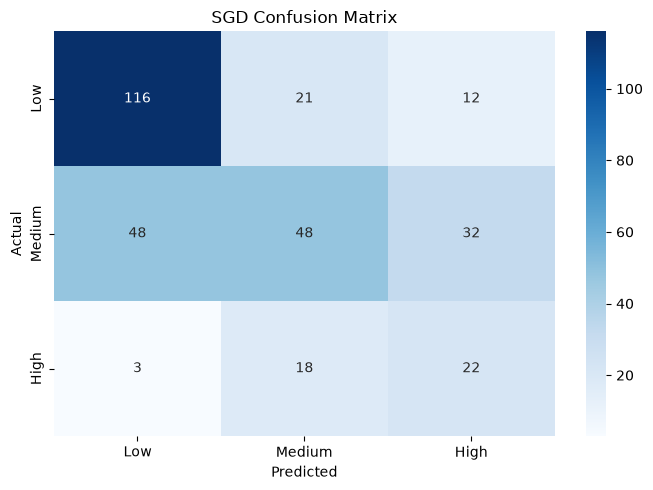

In [43]:
sgd_cm = confusion_matrix(
    y_test,
    sgd_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("SGD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("../images/sgd_confusion_matrix.png", dpi=300)

plt.show()

## 10. Model 3 — Support Vector Classifier

Support Vector Classifier attempts to find decision boundaries that separate the classes.

An RBF kernel is used to allow nonlinear decision boundaries.

StandardScaler is applied because SVC is sensitive to feature scale.

In [46]:
from sklearn.svm import SVC
svc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=42
    ))
])

svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)

svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", round(svc_accuracy, 4))

SVC Accuracy: 0.6094


In [47]:
print("SVC Classification Report:\n")

print(
    classification_report(
        y_test,
        svc_pred,
        labels=["Low", "Medium", "High"],
        zero_division=0
    )
)

SVC Classification Report:

              precision    recall  f1-score   support

         Low       0.73      0.77      0.75       149
      Medium       0.57      0.40      0.47       128
        High       0.41      0.70      0.51        43

    accuracy                           0.61       320
   macro avg       0.57      0.62      0.58       320
weighted avg       0.62      0.61      0.60       320



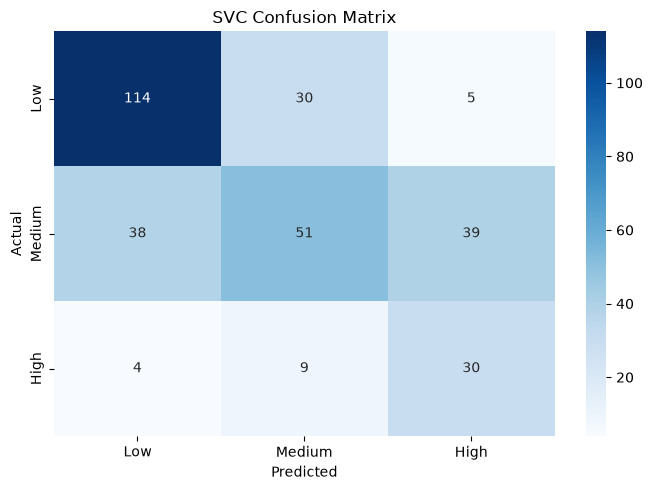

In [48]:
svc_cm = confusion_matrix(
    y_test,
    svc_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("../images/svc_confusion_matrix.png", dpi=300)

plt.show()

## 11. Model Comparison

The three classification models are compared using accuracy, macro-average precision, macro-average recall and macro-average F1-score.

Macro averages give equal importance to each class and are therefore useful when the dataset is imbalanced.

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

models_predictions = {
    "Random Forest": rf_pred,
    "SGD": sgd_pred,
    "SVC": svc_pred
}

for model_name, predictions in models_predictions.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro Precision": precision_score(
            y_test, predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test, predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_test, predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.7375,0.7032,0.7353,0.7156
1,SGD,0.5812,0.5266,0.5551,0.5281
2,SVC,0.6094,0.5676,0.6204,0.5761


In [50]:
comparison_table = results_df.copy()

for column in comparison_table.columns[1:]:
    comparison_table[column] = (
        comparison_table[column] * 100
    ).round(2).astype(str) + "%"

comparison_table

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,73.75%,70.32%,73.53%,71.56%
1,SGD,58.13%,52.66%,55.51%,52.81%
2,SVC,60.94%,56.76%,62.04%,57.61%


## 12. Random Forest Feature Importance

Random Forest provides feature importance values that indicate how much each physicochemical feature contributed to the trained forest's decision-making process.

In [51]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.167002
9,sulphates,0.115536
1,volatile acidity,0.112465
6,total sulfur dioxide,0.094816
2,citric acid,0.086781
7,density,0.083796
4,chlorides,0.074134
0,fixed acidity,0.071642
8,pH,0.066803
5,free sulfur dioxide,0.064319


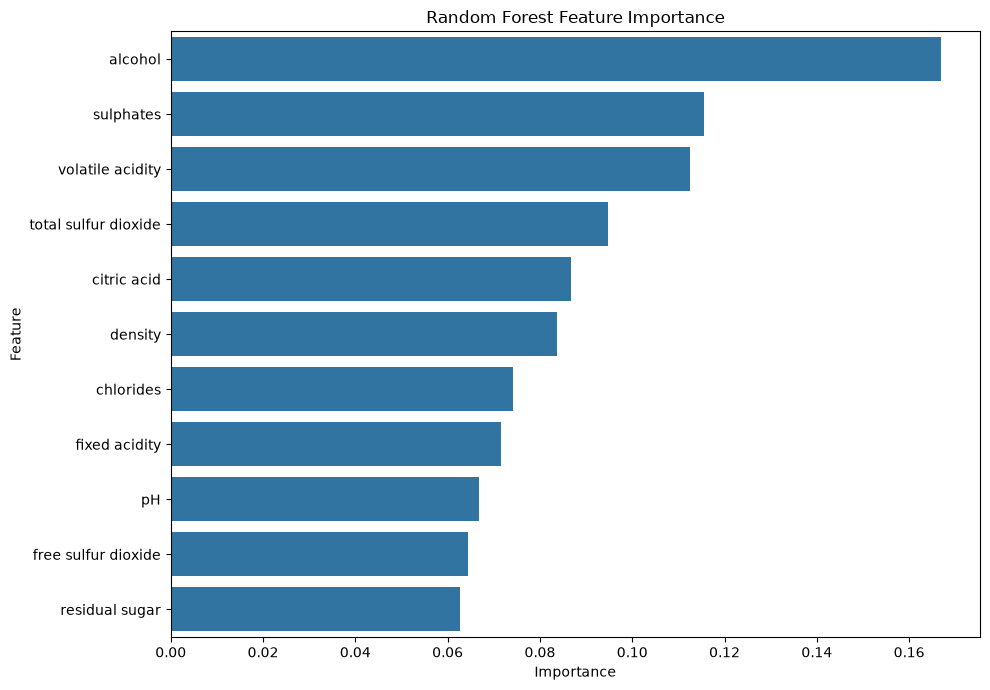

In [52]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../images/random_forest_feature_importance.png",
    dpi=300
)

plt.show()

### Feature Importance Observation

The Random Forest feature-importance chart shows which physicochemical variables contributed most strongly to the model's predictions.

The exact ordering should be interpreted from the generated chart rather than assumed beforehand.

Feature importance indicates contribution to the model's predictive decisions; it does not prove that a feature causally determines wine quality.

## 13. Model Performance Comparison

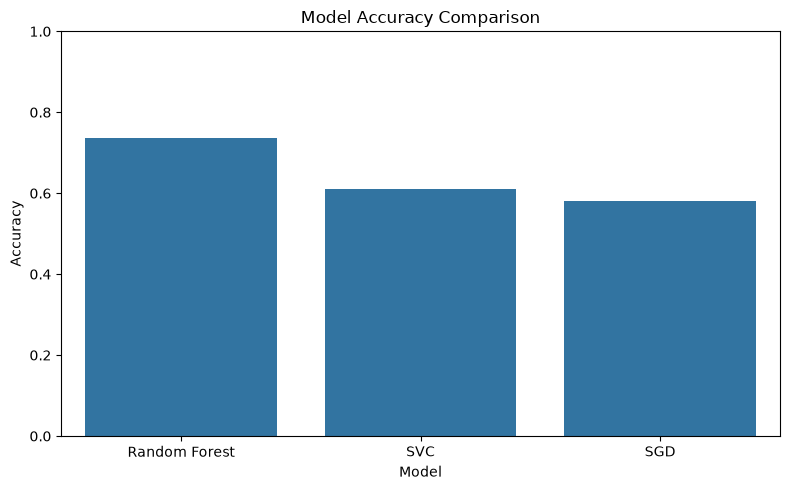

In [53]:
plot_results = results_df.copy()

plot_results = plot_results.sort_values(
    "Accuracy",
    ascending=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "../images/model_accuracy_comparison.png",
    dpi=300
)

plt.show()

## 14. Detailed Model Evaluation

In [54]:
print("=" * 70)
print("RANDOM FOREST")
print("=" * 70)
print(classification_report(
    y_test,
    rf_pred,
    labels=["Low", "Medium", "High"],
    zero_division=0
))

print("=" * 70)
print("SGD")
print("=" * 70)
print(classification_report(
    y_test,
    sgd_pred,
    labels=["Low", "Medium", "High"],
    zero_division=0
))

print("=" * 70)
print("SVC")
print("=" * 70)
print(classification_report(
    y_test,
    svc_pred,
    labels=["Low", "Medium", "High"],
    zero_division=0
))

RANDOM FOREST
              precision    recall  f1-score   support

         Low       0.82      0.81      0.81       149
      Medium       0.71      0.66      0.68       128
        High       0.58      0.74      0.65        43

    accuracy                           0.74       320
   macro avg       0.70      0.74      0.72       320
weighted avg       0.74      0.74      0.74       320

SGD
              precision    recall  f1-score   support

         Low       0.69      0.78      0.73       149
      Medium       0.55      0.38      0.45       128
        High       0.33      0.51      0.40        43

    accuracy                           0.58       320
   macro avg       0.53      0.56      0.53       320
weighted avg       0.59      0.58      0.57       320

SVC
              precision    recall  f1-score   support

         Low       0.73      0.77      0.75       149
      Medium       0.57      0.40      0.47       128
        High       0.41      0.70      0.51        43

## 15. Conclusion

The Wine Quality dataset was successfully transformed from an ordinal quality-score problem into a three-class classification problem consisting of Low, Medium and High quality wines.

Random Forest, Stochastic Gradient Descent and Support Vector Classifier were trained and evaluated.

Because the classes are imbalanced, accuracy alone is not sufficient for model comparison. Macro F1-score is also considered because it gives equal importance to each quality class.

The model results should be interpreted using accuracy, macro precision, macro recall, macro F1-score and the confusion matrices.

In [55]:
best_model = results_df.loc[
    results_df["Macro F1"].idxmax(),
    "Model"
]

best_f1 = results_df["Macro F1"].max()

print("Model with the highest Macro F1-score:", best_model)
print("Macro F1-score:", round(best_f1, 4))

Model with the highest Macro F1-score: Random Forest
Macro F1-score: 0.7156


### Final Interpretation

The model selected using Macro F1-score provides the strongest overall balance across the Low, Medium and High quality classes in this experiment.

The Random Forest feature-importance analysis also provides an interpretable view of the physicochemical variables used by the ensemble model.

For deployment, model selection should consider not only predictive performance but also computational requirements, interpretability, prediction speed and the consequences of misclassifying different wine-quality classes.

## Dataset Source

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009).

Wine Quality.

UCI Machine Learning Repository.

DOI: 10.24432/C56S3T

Source:
https://archive.ics.uci.edu/dataset/186/wine+quality